# Transaction Linking Evaluation

Re-computes evaluation from raw pipeline outputs, stratifies all metrics by difficulty
(easy / medium / hard), and presents both a stakeholder summary and engineering deep-dive.

**Data files** (same directory as this notebook):

| File | Records | Purpose |
|---|---|---|
| `transaction_links.jsonl` | 110 | Pipeline output — predicted matches |
| `transaction_links.yml` | ~110 entries | Ground truth with `match_difficulty` |
| `cleaned_extractions.jsonl` | 165 | Upstream extractions (for tracing errors) |

---
## Section 1: Setup & Data Loading

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

sns.set_theme(style="whitegrid")

# Consistent palette
DIFF_PALETTE = {"easy": "#4CAF50", "medium": "#FF9800", "hard": "#F44336"}
CORRECT_PALETTE = {True: "#4CAF50", False: "#F44336"}

DATA_DIR = Path(".").resolve()
print(f"Data directory: {DATA_DIR}")

Data directory: /Users/tod/Desktop/evaluation_data/synthetic_transaction_linking


In [2]:
# --- Load predictions ---
pred_records = []
with open(DATA_DIR / "transaction_links.jsonl") as f:
    for line in f:
        pred_records.append(json.loads(line.strip()))

pred_df = pd.DataFrame(pred_records)
print(f"Predictions loaded: {len(pred_df)} records")
pred_df.head(2)

Predictions loaded: 110 records


,image_name,case_id,document_type,supplier_name,receipt_date,receipt_total,matched,confidence,match_scores,reasoning,bank_statement_file,bank_transaction_date,bank_transaction_description,bank_transaction_amount
0,CASE001_receipt_thermal_80mm.png,CASE001,RECEIPT,Bunnings Warehouse,NOT_FOUND,34.16,True,LOW,"{'amount': 1.0, 'date': 0.0, 'description': 0.0}",Hybrid fallback: Exact amount ($34.16),CASE001_cba_standard.png,06/01/2023,VISA DEBIT PURCHASE Big W Alexandria AU,34.16
1,CASE001_tax_invoice_standard.png,CASE001,RECEIPT,Tax Invoice,17/04/2023,6493.84,False,NONE,{},No matching debit transaction found with the a...,NaN,NaN,NaN,NaN


In [3]:
# --- Load ground truth ---
with open(DATA_DIR / "transaction_links.yml") as f:
    gt_raw = yaml.safe_load(f)

gt_rows = []
for image_name, entries in gt_raw.items():
    for entry in entries:
        gt_rows.append({
            "image_name": image_name,
            "gt_supplier": entry.get("supplier", ""),
            "gt_receipt_date": str(entry.get("receipt_date", "")),
            "gt_receipt_total": float(entry["receipt_total"]) if entry.get("receipt_total") not in (None, "") else None,
            "gt_bank_date": str(entry.get("bank_date", "")),
            "gt_bank_description": str(entry.get("bank_description", "")),
            "gt_bank_amount": float(entry["bank_amount"]) if entry.get("bank_amount") not in (None, "") else None,
            "gt_match_status": str(entry.get("match_status", "FOUND")).upper(),
            "match_difficulty": entry.get("match_difficulty", "unknown"),
            "gt_notes": entry.get("notes", ""),
            "gt_bank_statement": entry.get("bank_statement", ""),
        })

gt_df = pd.DataFrame(gt_rows)
print(f"Ground truth loaded: {len(gt_df)} entries across {gt_df['image_name'].nunique()} images")
gt_df.head(2)

Ground truth loaded: 110 entries across 110 images


,image_name,gt_supplier,gt_receipt_date,gt_receipt_total,gt_bank_date,gt_bank_description,gt_bank_amount,gt_match_status,match_difficulty,gt_notes,gt_bank_statement
0,CASE001_receipt_thermal_80mm.png,Bunnings Warehouse,08/04/2023,34.16,08/04/2023,VISA DEBIT PURCHASE BUNNINGS W/HOUSE Alexandri...,34.16,FOUND,easy,Early row on cba standard — exact date and amo...,CASE001_cba_standard.png
1,CASE001_tax_invoice_standard.png,Smith & Associates Accounting,17/04/2023,6493.84,17/04/2023,BPAY SMITH ASSOCIATES CRN 890779946,6493.84,FOUND,easy,Mid row on cba standard — exact date and amoun...,CASE001_cba_standard.png


In [4]:
# --- Join predictions <-> ground truth ---
# For multi-receipt images, match on (image_name, receipt_total)
# First try exact join on image_name + amount, then fall back to image_name only

pred_df["_join_amount"] = pred_df["receipt_total"].apply(
    lambda x: round(float(x), 2) if pd.notna(x) else None
)
gt_df["_join_amount"] = gt_df["gt_receipt_total"].apply(
    lambda x: round(float(x), 2) if pd.notna(x) else None
)

merged = pred_df.merge(
    gt_df,
    on=["image_name", "_join_amount"],
    how="left",
    suffixes=("", "_gt"),
)

# Fall back to image_name-only join for any unmatched rows
unmatched_mask = merged["match_difficulty"].isna()
if unmatched_mask.any():
    unmatched_images = merged.loc[unmatched_mask, "image_name"].unique()
    fallback = pred_df[pred_df["image_name"].isin(unmatched_images)].merge(
        gt_df, on="image_name", how="left", suffixes=("", "_gt")
    )
    merged = pd.concat(
        [merged[~unmatched_mask], fallback], ignore_index=True
    )

merged.drop(columns=["_join_amount"], inplace=True, errors="ignore")
print(f"Merged dataset: {len(merged)} rows")
print(f"Difficulty distribution:\n{merged['match_difficulty'].value_counts().to_string()}")

# Validation: no NaN in difficulty
n_missing = merged["match_difficulty"].isna().sum()
if n_missing:
    print(f"\nWARNING: {n_missing} rows have no difficulty annotation")
else:
    print("\nAll rows have difficulty annotations.")

Merged dataset: 110 rows
Difficulty distribution:
match_difficulty
easy      48
medium    41
hard      21

All rows have difficulty annotations.


---
## Section 1b: Evaluation Logic

Replicate matching logic from `stages/evaluate_linking.py`.

In [5]:
def amount_match(predicted, expected, tolerance=0.01):
    """Amount is correct if within $0.01."""
    if pd.isna(predicted) or pd.isna(expected):
        return False
    return abs(float(predicted) - float(expected)) <= tolerance


def date_match(predicted, expected):
    """Exact string match after stripping whitespace (DD/MM/YYYY)."""
    p = str(predicted).strip() if pd.notna(predicted) else ""
    e = str(expected).strip() if pd.notna(expected) else ""
    if not p or not e:
        return False
    return p == e


def description_match(actual, expected):
    """Bidirectional substring OR >= 50% keyword overlap (case-insensitive)."""
    a = str(actual).strip().upper() if pd.notna(actual) else ""
    e = str(expected).strip().upper() if pd.notna(expected) else ""
    if not a or not e:
        return False
    if a == e:
        return True
    if e in a or a in e:
        return True
    expected_words = set(e.split())
    actual_words = set(a.split())
    if expected_words:
        overlap = len(expected_words & actual_words)
        return overlap >= len(expected_words) * 0.5
    return False


# Apply evaluation
merged["expected_found"] = merged["gt_match_status"] == "FOUND"
merged["actual_found"] = merged["matched"].fillna(False).astype(bool)
merged["match_status_correct"] = merged["expected_found"] == merged["actual_found"]

# Field-level checks (only meaningful when both expected and actual are FOUND)
both_found = merged["expected_found"] & merged["actual_found"]

merged["amount_correct"] = False
merged.loc[both_found, "amount_correct"] = merged.loc[both_found].apply(
    lambda r: amount_match(r["bank_transaction_amount"], r["gt_bank_amount"]), axis=1
)

merged["date_correct"] = False
merged.loc[both_found, "date_correct"] = merged.loc[both_found].apply(
    lambda r: date_match(r["bank_transaction_date"], r["gt_bank_date"]), axis=1
)

merged["desc_correct"] = False
merged.loc[both_found, "desc_correct"] = merged.loc[both_found].apply(
    lambda r: description_match(r["bank_transaction_description"], r["gt_bank_description"]), axis=1
)

# Overall correctness:
# - If expected NOT_FOUND and actual not found -> correct
# - If expected FOUND and actual found and matched to RIGHT transaction -> correct
# - Otherwise -> incorrect
merged["correct"] = False
# Case 1: both not found
merged.loc[~merged["expected_found"] & ~merged["actual_found"], "correct"] = True
# Case 2: both found AND matched to correct transaction (amount must match)
merged.loc[
    both_found & merged["amount_correct"],
    "correct",
] = True

print("Evaluation computed.")
print(f"Overall accuracy: {merged['correct'].mean():.1%} ({merged['correct'].sum()}/{len(merged)})")

Evaluation computed.
Overall accuracy: 53.6% (59/110)


---
## Section 2: Executive Summary

In [6]:
total = len(merged)
correct_count = merged["correct"].sum()
accuracy = correct_count / total * 100

print(f"{'='*50}")
print(f" OVERALL MATCH ACCURACY: {accuracy:.1f}%  ({correct_count}/{total})")
print(f"{'='*50}")

 OVERALL MATCH ACCURACY: 53.6%  (59/110)


In [7]:
# --- Accuracy by difficulty ---
diff_order = ["easy", "medium", "hard"]
rows = []
for diff in diff_order:
    subset = merged[merged["match_difficulty"] == diff]
    n = len(subset)
    n_correct = subset["correct"].sum()
    acc = n_correct / n * 100 if n else 0
    fp = ((~subset["expected_found"]) & subset["actual_found"]).sum()
    fn = (subset["expected_found"] & (~subset["actual_found"])).sum()
    rows.append({
        "Difficulty": diff,
        "Total": n,
        "Correct": int(n_correct),
        "Accuracy %": f"{acc:.1f}%",
        "False Pos": int(fp),
        "False Neg": int(fn),
    })

# Add overall row
fp_all = ((~merged["expected_found"]) & merged["actual_found"]).sum()
fn_all = (merged["expected_found"] & (~merged["actual_found"])).sum()
rows.append({
    "Difficulty": "ALL",
    "Total": total,
    "Correct": int(correct_count),
    "Accuracy %": f"{accuracy:.1f}%",
    "False Pos": int(fp_all),
    "False Neg": int(fn_all),
})

difficulty_table = pd.DataFrame(rows).set_index("Difficulty")
difficulty_table.style.set_caption("Accuracy by Difficulty")

,Total,Correct,Accuracy %,False Pos,False Neg
Difficulty,,,,,
easy,48,25,52.1%,0,20
medium,41,23,56.1%,0,18
hard,21,11,52.4%,0,9
ALL,110,59,53.6%,0,47


In [8]:
# --- Field-level accuracy ---
found_both = merged[both_found]
field_rows = []
for diff in diff_order + ["ALL"]:
    subset = found_both if diff == "ALL" else found_both[found_both["match_difficulty"] == diff]
    n = len(subset)
    if n == 0:
        field_rows.append({"Difficulty": diff, "N (both found)": 0,
                           "Amount %": "-", "Date %": "-", "Description %": "-"})
        continue
    field_rows.append({
        "Difficulty": diff,
        "N (both found)": n,
        "Amount %": f"{subset['amount_correct'].mean():.1%}",
        "Date %": f"{subset['date_correct'].mean():.1%}",
        "Description %": f"{subset['desc_correct'].mean():.1%}",
    })

field_table = pd.DataFrame(field_rows).set_index("Difficulty")
field_table.style.set_caption("Field-Level Accuracy (where both expected & actual FOUND)")

,N (both found),Amount %,Date %,Description %
Difficulty,,,,
easy,28,89.3%,32.1%,60.7%
medium,23,100.0%,17.4%,52.2%
hard,12,91.7%,16.7%,66.7%
ALL,63,93.7%,23.8%,58.7%


In [9]:
# --- Confidence calibration table ---
conf_rows = []
for level in ["HIGH", "MEDIUM", "LOW", "NONE"]:
    subset = merged[merged["confidence"] == level]
    n = len(subset)
    if n == 0:
        continue
    n_correct = subset["correct"].sum()
    conf_rows.append({
        "Confidence": level,
        "Count": n,
        "Correct": int(n_correct),
        "Accuracy %": f"{n_correct / n:.1%}",
    })

conf_table = pd.DataFrame(conf_rows).set_index("Confidence")
conf_table.style.set_caption("Confidence Calibration: Does confidence predict correctness?")

,Count,Correct,Accuracy %
Confidence,,,
HIGH,40,39,97.5%
MEDIUM,11,8,72.7%
LOW,12,12,100.0%
NONE,47,0,0.0%


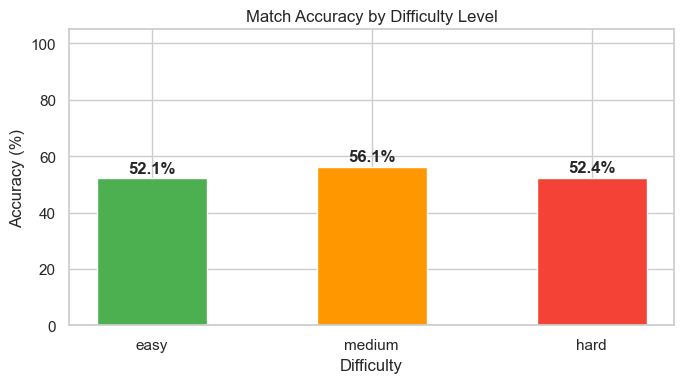

In [10]:
# --- Summary bar chart: accuracy by difficulty ---
fig, ax = plt.subplots(figsize=(7, 4))
acc_by_diff = merged.groupby("match_difficulty")["correct"].mean().reindex(diff_order) * 100
bars = ax.bar(diff_order, acc_by_diff.values,
              color=[DIFF_PALETTE[d] for d in diff_order], edgecolor="white", width=0.5)

for bar, val in zip(bars, acc_by_diff.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Difficulty")
ax.set_title("Match Accuracy by Difficulty Level")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

### Accuracy by Document Type

Receipt vs Invoice breakdown, and cross-tabulated with difficulty.

In [ ]:
# Derive document type from image name (document_type column is unreliable)
merged["doc_type"] = merged["image_name"].apply(
    lambda x: "Invoice" if "invoice" in x.lower() else "Receipt"
)

DOC_TYPES = ["Receipt", "Invoice"]
DOC_PALETTE = {"Receipt": "#2196F3", "Invoice": "#FF9800"}

# --- Accuracy by document type table ---
doc_rows = []
for dt in DOC_TYPES:
    subset = merged[merged["doc_type"] == dt]
    n = len(subset)
    n_correct = subset["correct"].sum()
    acc = n_correct / n * 100 if n else 0
    fp = ((~subset["expected_found"]) & subset["actual_found"]).sum()
    fn = (subset["expected_found"] & (~subset["actual_found"])).sum()
    doc_rows.append({
        "Document Type": dt,
        "Total": n,
        "Correct": int(n_correct),
        "Accuracy %": f"{acc:.1f}%",
        "False Pos": int(fp),
        "False Neg": int(fn),
    })

doc_table = pd.DataFrame(doc_rows).set_index("Document Type")
doc_table.style.set_caption("Accuracy by Document Type")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy by document type
doc_accs = [merged[merged["doc_type"] == dt]["correct"].mean() * 100 for dt in DOC_TYPES]
doc_counts = [len(merged[merged["doc_type"] == dt]) for dt in DOC_TYPES]

bars = axes[0].bar(DOC_TYPES, doc_accs,
                   color=[DOC_PALETTE[dt] for dt in DOC_TYPES],
                   edgecolor="white", width=0.5)
for bar, val, cnt in zip(bars, doc_accs, doc_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}%\n(n={cnt})", ha="center", va="bottom", fontweight="bold")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Match Accuracy by Document Type")
axes[0].set_ylim(0, 115)

# Right: document type × difficulty
doc_diff_data = []
for dt in DOC_TYPES:
    for diff in diff_order:
        subset = merged[(merged["doc_type"] == dt) & (merged["match_difficulty"] == diff)]
        n = len(subset)
        if n == 0:
            continue
        doc_diff_data.append({
            "Document Type": dt,
            "Difficulty": diff,
            "Accuracy %": subset["correct"].mean() * 100,
            "Count": n,
        })

doc_diff_df = pd.DataFrame(doc_diff_data)
sns.barplot(data=doc_diff_df, x="Document Type", y="Accuracy %", hue="Difficulty",
            hue_order=diff_order, palette=DIFF_PALETTE, ax=axes[1], edgecolor="white")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f%%", fontsize=9, padding=2)
axes[1].set_title("Accuracy by Document Type × Difficulty")
axes[1].set_ylim(0, 115)
axes[1].legend(title="Difficulty")

plt.tight_layout()
plt.show()

---
## Section 3: Detailed Analysis

### 3a. Confusion Matrix

Expected FOUND / NOT_FOUND vs actual matched / unmatched.

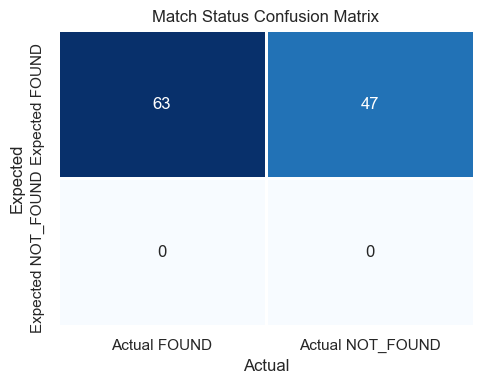

In [11]:
# Build confusion matrix
merged["_expected"] = merged["expected_found"].map({True: "Expected FOUND", False: "Expected NOT_FOUND"})
merged["_actual"] = merged["actual_found"].map({True: "Actual FOUND", False: "Actual NOT_FOUND"})

cm = pd.crosstab(merged["_expected"], merged["_actual"],
                  rownames=["Expected"], colnames=["Actual"])
# Reorder for conventional layout
row_order = ["Expected FOUND", "Expected NOT_FOUND"]
col_order = ["Actual FOUND", "Actual NOT_FOUND"]
cm = cm.reindex(index=row_order, columns=col_order, fill_value=0)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            linewidths=1, linecolor="white", ax=ax)
ax.set_title("Match Status Confusion Matrix")
plt.tight_layout()
plt.show()

merged.drop(columns=["_expected", "_actual"], inplace=True)

### 3b. Field-Level Accuracy Breakdown

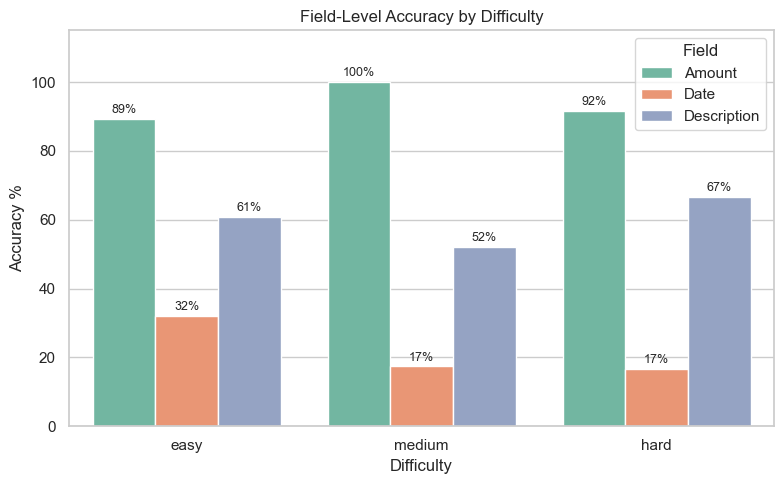

In [12]:
# Grouped bar chart: field accuracy per difficulty
field_data = []
for diff in diff_order:
    subset = found_both[found_both["match_difficulty"] == diff]
    n = len(subset)
    if n == 0:
        continue
    for field, col in [("Amount", "amount_correct"), ("Date", "date_correct"), ("Description", "desc_correct")]:
        field_data.append({
            "Difficulty": diff,
            "Field": field,
            "Accuracy %": subset[col].mean() * 100,
        })

field_plot_df = pd.DataFrame(field_data)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=field_plot_df, x="Difficulty", y="Accuracy %", hue="Field",
            order=diff_order, palette="Set2", ax=ax, edgecolor="white")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", fontsize=9, padding=2)

ax.set_title("Field-Level Accuracy by Difficulty")
ax.set_ylim(0, 115)
ax.legend(title="Field")
plt.tight_layout()
plt.show()

In [13]:
# Table of most common field failures
failures = []
for _, r in found_both.iterrows():
    for field, col in [("amount", "amount_correct"), ("date", "date_correct"), ("description", "desc_correct")]:
        if not r[col]:
            failures.append({
                "image_name": r["image_name"],
                "difficulty": r["match_difficulty"],
                "field": field,
            })

if failures:
    fail_df = pd.DataFrame(failures)
    print("Most common field failure combinations:")
    print(fail_df.groupby(["field", "difficulty"]).size().unstack(fill_value=0).to_string())
else:
    print("No field failures detected.")

Most common field failure combinations:
difficulty   easy  hard  medium
field                          
amount          3     1       0
date           19    10      19
description    11     4      11


### 3c. Confidence Calibration

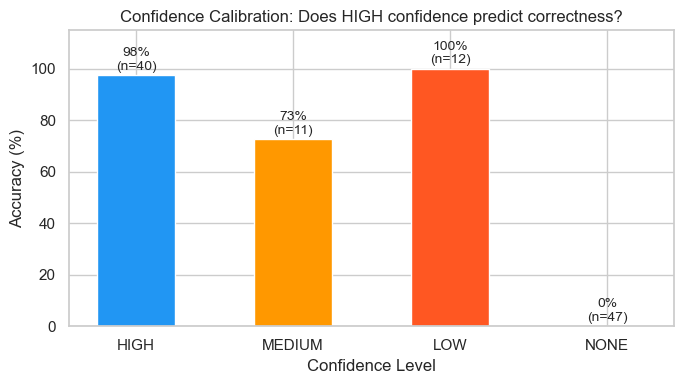

In [14]:
# Bar chart: confidence level vs accuracy with count annotations
conf_levels = ["HIGH", "MEDIUM", "LOW", "NONE"]
conf_acc = []
conf_counts = []
for level in conf_levels:
    subset = merged[merged["confidence"] == level]
    n = len(subset)
    conf_counts.append(n)
    conf_acc.append(subset["correct"].mean() * 100 if n else 0)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(conf_levels, conf_acc, color=["#2196F3", "#FF9800", "#FF5722", "#9E9E9E"],
              edgecolor="white", width=0.5)
for bar, val, cnt in zip(bars, conf_acc, conf_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.0f}%\n(n={cnt})", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Confidence Level")
ax.set_title("Confidence Calibration: Does HIGH confidence predict correctness?")
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

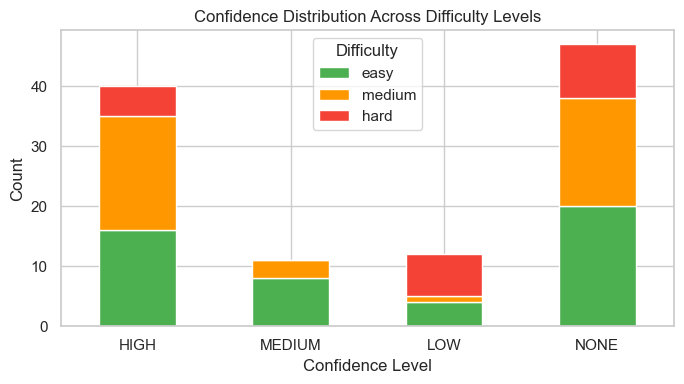

In [15]:
# Stacked bar: confidence distribution across difficulty levels
conf_diff = pd.crosstab(merged["confidence"], merged["match_difficulty"])
conf_diff = conf_diff.reindex(index=conf_levels, columns=diff_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
conf_diff.plot(kind="bar", stacked=True, color=[DIFF_PALETTE[d] for d in diff_order],
               edgecolor="white", ax=ax)
ax.set_title("Confidence Distribution Across Difficulty Levels")
ax.set_ylabel("Count")
ax.set_xlabel("Confidence Level")
ax.legend(title="Difficulty")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3d. Error Analysis

In [16]:
# Filter to incorrect predictions
errors = merged[~merged["correct"]].copy()
print(f"Total errors: {len(errors)}")

# Categorize errors
def categorize_error(row):
    expected_found = row["expected_found"]
    actual_found = row["actual_found"]
    if expected_found and actual_found:
        return "wrong_transaction"  # matched but to the wrong one
    if expected_found and not actual_found:
        return "missed_match"  # should have found but didn't
    if not expected_found and actual_found:
        return "false_match"  # found but shouldn't have
    return "other"

errors["error_type"] = errors.apply(categorize_error, axis=1)

print("\nError type breakdown:")
print(errors["error_type"].value_counts().to_string())

Total errors: 51

Error type breakdown:
error_type
missed_match         47
wrong_transaction     4


In [17]:
# Error detail table
error_detail_cols = [
    "image_name", "match_difficulty", "error_type",
    "gt_match_status", "matched", "confidence",
    "receipt_total", "gt_bank_amount",
    "bank_transaction_description", "gt_bank_description",
    "reasoning",
]
available_cols = [c for c in error_detail_cols if c in errors.columns]
error_display = errors[available_cols].copy()
error_display["reasoning"] = error_display["reasoning"].str[:120]

# Sort by difficulty (hard first)
diff_sort = {"hard": 0, "medium": 1, "easy": 2}
error_display["_sort"] = error_display["match_difficulty"].map(diff_sort)
error_display = error_display.sort_values("_sort").drop(columns="_sort")

print(f"Error details ({len(error_display)} records):")
error_display.reset_index(drop=True)

Error details (51 records):


,image_name,match_difficulty,error_type,gt_match_status,matched,confidence,receipt_total,gt_bank_amount,bank_transaction_description,gt_bank_description,reasoning
0,CASE055_tax_invoice_high_value.png,hard,wrong_transaction,FOUND,True,HIGH,23210.41,21202.41,DD AGIL 152737 MFH 1234,EFTPOS JB HI-FI Subiaco AUS,The transaction amount matches the receipt tot...
1,CASE023_tax_invoice_high_value.png,hard,missed_match,FOUND,False,NONE,12802.14,12802.14,NaN,EFTPOS JB HI-FI Fortitude Valley AUS,"No debit transaction with an amount of $12,802..."
2,CASE025_receipt_thermal_80mm.png,hard,missed_match,FOUND,False,NONE,260.44,260.44,NaN,EFTPOS JB HI-FI Subiaco AUS,No matching debit transaction amount found in ...
3,CASE041_receipt_professional.png,hard,missed_match,FOUND,False,NONE,106.06,106.06,NaN,Transfer To Thomas NetBank,No matching debit transaction amount found in ...
4,CASE030_tax_invoice_gst_inclusive.png,hard,missed_match,FOUND,False,NONE,27294.75,27294.75,NaN,EFTPOS DAN MURPHYS Glenelg AUS,No matching debit transaction found with the a...
5,CASE022_receipt_fuel.png,hard,missed_match,FOUND,False,NONE,10.23,10.23,NaN,EFTPOS JB HI-FI Hawthorn East AUS,No matching debit transaction found with the a...
6,CASE031_receipt_thermal_80mm.png,hard,missed_match,FOUND,False,NONE,158.41,158.41,NaN,EFTPOS KMART Alexandria AUS,No matching debit transaction found with the e...
7,CASE052_receipt_fuel.png,hard,missed_match,FOUND,False,NONE,90.15,90.15,NaN,EFTPOS TARGET Hawthorn East AUS,No matching debit transaction amount found in ...
8,CASE007_receipt_thermal_80mm.png,hard,missed_match,FOUND,False,NONE,55.09,55.09,NaN,BPAY ORIGIN ENERGY CRN 793773681,No matching debit transaction found with the a...
9,CASE007_tax_invoice_high_value.png,hard,missed_match,FOUND,False,NONE,6977.45,6977.45,NaN,VISA DEBIT PURCHASE SHELL Parramatta AU,No debit transaction with an amount of $6977.4...


### 3e. Date Extraction Quality

In [18]:
# Compare extracted receipt_date to ground truth
merged["receipt_date_extracted"] = merged["receipt_date"].apply(
    lambda x: str(x).strip() if pd.notna(x) else ""
)
merged["date_is_not_found"] = merged["receipt_date_extracted"].isin(["", "NOT_FOUND", "None", "nan"])

n_not_found = merged["date_is_not_found"].sum()
n_extracted = (~merged["date_is_not_found"]).sum()
print(f"Receipt dates extracted: {n_extracted}")
print(f"Receipt dates NOT_FOUND: {n_not_found}")

# For extracted dates: how many match the ground truth?
extracted_dates = merged[~merged["date_is_not_found"]].copy()
extracted_dates["receipt_date_correct"] = extracted_dates.apply(
    lambda r: date_match(r["receipt_date_extracted"], r["gt_receipt_date"]), axis=1
)

n_date_correct = extracted_dates["receipt_date_correct"].sum()
print(f"\nOf {n_extracted} extracted dates: {n_date_correct} correct ({n_date_correct/n_extracted:.1%})")

# Date proximity analysis
from datetime import datetime

def days_between(d1_str, d2_str):
    try:
        d1 = datetime.strptime(str(d1_str).strip(), "%d/%m/%Y")
        d2 = datetime.strptime(str(d2_str).strip(), "%d/%m/%Y")
        return abs((d1 - d2).days)
    except (ValueError, TypeError):
        return None

extracted_dates["days_off"] = extracted_dates.apply(
    lambda r: days_between(r["receipt_date_extracted"], r["gt_receipt_date"]), axis=1
)

for n_days in [0, 1, 3, 7]:
    within = (extracted_dates["days_off"] <= n_days).sum()
    print(f"  Within {n_days} days: {within}/{n_extracted} ({within/n_extracted:.1%})")

Receipt dates extracted: 55
Receipt dates NOT_FOUND: 55

Of 55 extracted dates: 35 correct (63.6%)
  Within 0 days: 35/55 (63.6%)
  Within 1 days: 36/55 (65.5%)
  Within 3 days: 38/55 (69.1%)
  Within 7 days: 40/55 (72.7%)


In [19]:
# Date extraction by difficulty
date_by_diff = []
for diff in diff_order:
    subset = merged[merged["match_difficulty"] == diff]
    n = len(subset)
    n_nf = subset["date_is_not_found"].sum()
    ext = subset[~subset["date_is_not_found"]]
    n_ext = len(ext)
    date_by_diff.append({
        "Difficulty": diff,
        "Total": n,
        "Date Extracted": n_ext,
        "Date NOT_FOUND": int(n_nf),
        "Extraction Rate": f"{n_ext/n:.1%}" if n else "-",
    })

pd.DataFrame(date_by_diff).set_index("Difficulty")

,Total,Date Extracted,Date NOT_FOUND,Extraction Rate
Difficulty,,,,
easy,48,23,25,47.9%
medium,41,23,18,56.1%
hard,21,9,12,42.9%


### 3f. VLM vs Hybrid Fallback

In [20]:
# Classify reasoning into VLM direct vs hybrid fallback
merged["pathway"] = merged["reasoning"].apply(
    lambda r: "Hybrid fallback" if pd.notna(r) and "hybrid fallback" in str(r).lower()
    else ("No match" if pd.notna(r) and ("no matching" in str(r).lower() or "no debit" in str(r).lower())
          else "VLM direct")
)

pathway_rows = []
for pathway in ["VLM direct", "Hybrid fallback", "No match"]:
    subset = merged[merged["pathway"] == pathway]
    n = len(subset)
    if n == 0:
        continue
    n_correct = subset["correct"].sum()
    pathway_rows.append({
        "Pathway": pathway,
        "Count": n,
        "Correct": int(n_correct),
        "Accuracy": f"{n_correct/n:.1%}",
    })

pathway_table = pd.DataFrame(pathway_rows).set_index("Pathway")
print("VLM Direct vs Hybrid Fallback Accuracy:")
pathway_table

VLM Direct vs Hybrid Fallback Accuracy:


,Count,Correct,Accuracy
Pathway,,,
VLM direct,43,39,90.7%
Hybrid fallback,20,20,100.0%
No match,47,0,0.0%


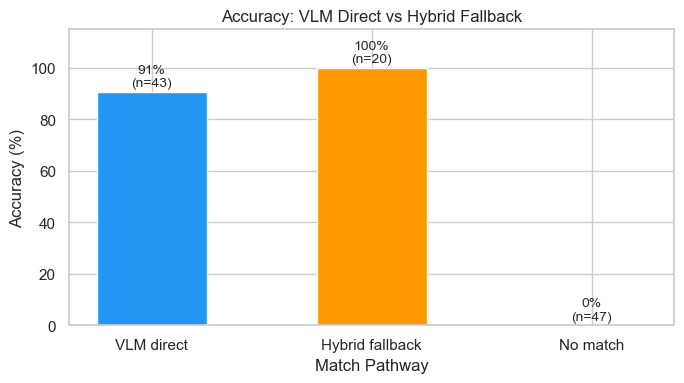

In [21]:
# Chart: pathway accuracy side by side
pathways = [r["Pathway"] for r in pathway_rows]
p_accs = [merged[merged["pathway"] == p]["correct"].mean() * 100 for p in pathways]
p_counts = [len(merged[merged["pathway"] == p]) for p in pathways]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(pathways, p_accs, color=["#2196F3", "#FF9800", "#9E9E9E"][:len(pathways)],
              edgecolor="white", width=0.5)
for bar, val, cnt in zip(bars, p_accs, p_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.0f}%\n(n={cnt})", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Match Pathway")
ax.set_title("Accuracy: VLM Direct vs Hybrid Fallback")
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

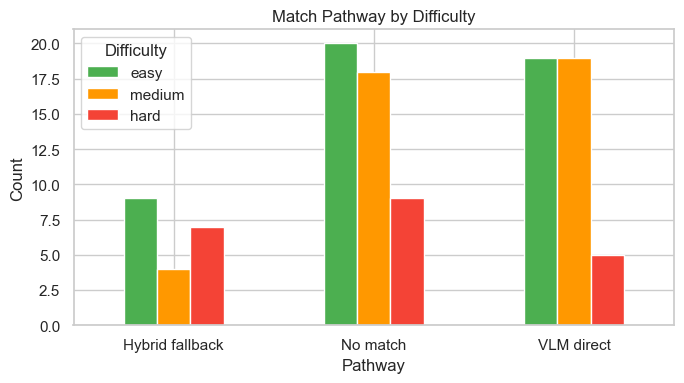

In [22]:
# Pathway breakdown by difficulty
pathway_diff = pd.crosstab(merged["pathway"], merged["match_difficulty"])
pathway_diff = pathway_diff.reindex(columns=diff_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
pathway_diff.plot(kind="bar", color=[DIFF_PALETTE[d] for d in diff_order],
                  edgecolor="white", ax=ax)
ax.set_title("Match Pathway by Difficulty")
ax.set_ylabel("Count")
ax.set_xlabel("Pathway")
ax.legend(title="Difficulty")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Section 4: Per-Case Detail Table

Full table sorted by: incorrect first, then by difficulty (hard -> easy).

In [23]:
detail_cols = [
    "image_name", "match_difficulty", "gt_match_status", "matched",
    "correct", "confidence", "amount_correct", "date_correct", "desc_correct",
    "reasoning",
]
available = [c for c in detail_cols if c in merged.columns]
detail = merged[available].copy()
detail["reasoning"] = detail["reasoning"].str[:100]

# Sort: incorrect first, then hard -> medium -> easy
diff_sort_map = {"hard": 0, "medium": 1, "easy": 2}
detail["_sort_correct"] = detail["correct"].astype(int)  # 0 (incorrect) first
detail["_sort_diff"] = detail["match_difficulty"].map(diff_sort_map)
detail = detail.sort_values(["_sort_correct", "_sort_diff", "image_name"]).drop(
    columns=["_sort_correct", "_sort_diff"]
)

detail.reset_index(drop=True)

,image_name,match_difficulty,gt_match_status,matched,correct,confidence,amount_correct,date_correct,desc_correct,reasoning
0,CASE007_receipt_thermal_80mm.png,hard,FOUND,False,False,NONE,False,False,False,No matching debit transaction found with the a...
1,CASE007_tax_invoice_high_value.png,hard,FOUND,False,False,NONE,False,False,False,No debit transaction with an amount of $6977.4...
2,CASE022_receipt_fuel.png,hard,FOUND,False,False,NONE,False,False,False,No matching debit transaction found with the a...
3,CASE023_tax_invoice_high_value.png,hard,FOUND,False,False,NONE,False,False,False,"No debit transaction with an amount of $12,802..."
4,CASE025_receipt_thermal_80mm.png,hard,FOUND,False,False,NONE,False,False,False,No matching debit transaction amount found in ...
...,...,...,...,...,...,...,...,...,...,...
105,CASE047_receipt_professional.png,easy,FOUND,True,True,LOW,True,False,False,Hybrid fallback: Exact amount ($120.09)
106,CASE050_receipt_thermal_57mm.png,easy,FOUND,True,True,HIGH,True,True,True,The transaction amount matches the receipt tot...
107,CASE051_tax_invoice_high_value.png,easy,FOUND,True,True,HIGH,True,True,False,The transaction amount matches the receipt tot...
108,CASE052_tax_invoice_mixed.png,easy,FOUND,True,True,HIGH,True,False,False,The transaction amount matches the receipt tot...


In [24]:
# Validation: sum of difficulty levels == total
by_diff = merged["match_difficulty"].value_counts()
total_by_diff = by_diff.sum()
assert total_by_diff == total, f"Difficulty sum {total_by_diff} != total {total}"
print(f"Validation passed: easy({by_diff.get('easy', 0)}) + medium({by_diff.get('medium', 0)}) + hard({by_diff.get('hard', 0)}) = {total_by_diff} == {total}")

Validation passed: easy(48) + medium(41) + hard(21) = 110 == 110
